# Assignment - Sampling (Step by Step)

This notebook solves the assignment using `Creditcard_data.csv` (same original name).

In [1]:
# If any package is missing, run this once
%pip install pandas numpy scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/himayattiwana/Downloads/pred anal assigns/ds_env/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1) Load Dataset and Check Imbalance

In [3]:
df = pd.read_csv('Creditcard_data.csv')
print('Shape:', df.shape)
display(df.head())

if 'Class' not in df.columns:
    raise ValueError("Expected target column 'Class' not found.")

print('\nClass distribution (original):')
display(df['Class'].value_counts())
print('\nClass percentage (original):')
display((df['Class'].value_counts(normalize=True) * 100).round(2))

Shape: (772, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Class distribution (original):


Class
0    763
1      9
Name: count, dtype: int64


Class percentage (original):


Class
0    98.83
1     1.17
Name: proportion, dtype: float64

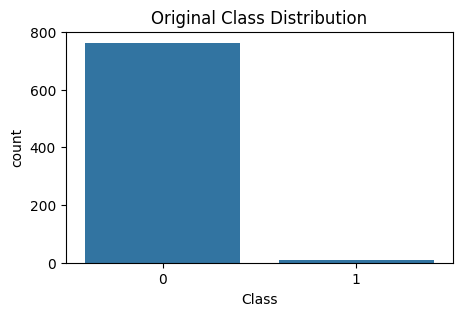

In [4]:
plt.figure(figsize=(5, 3))
sns.countplot(x='Class', data=df)
plt.title('Original Class Distribution')
plt.show()

## 2) Convert to Balanced Dataset
Using random undersampling of the majority class.

In [5]:
class_counts = df['Class'].value_counts()
minority_class = class_counts.idxmin()
majority_class = class_counts.idxmax()

minority_df = df[df['Class'] == minority_class]
majority_df = df[df['Class'] == majority_class].sample(
    n=len(minority_df), random_state=RANDOM_STATE
)

balanced_df = pd.concat([minority_df, majority_df], ignore_index=True)
balanced_df = balanced_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print('Balanced shape:', balanced_df.shape)
print('Balanced class distribution:')
display(balanced_df['Class'].value_counts())

Balanced shape: (18, 31)
Balanced class distribution:


Class
1    9
0    9
Name: count, dtype: int64

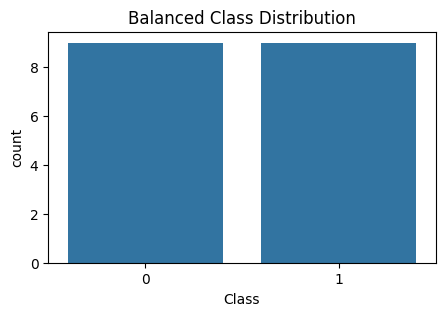

In [6]:
plt.figure(figsize=(5, 3))
sns.countplot(x='Class', data=balanced_df)
plt.title('Balanced Class Distribution')
plt.show()

## 3) Create 5 Sampling Methods (Sampling1...Sampling5)

In [7]:
train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=balanced_df['Class']
)

sample_size = int(len(train_df) * 0.8)
print('Train size:', len(train_df), '| Test size:', len(test_df), '| Sample size:', sample_size)

Train size: 14 | Test size: 4 | Sample size: 11


In [9]:
def simple_random_sampling(df, n, random_state=42):
    return df.sample(n=n, random_state=random_state).reset_index(drop=True)

def systematic_sampling(df, n, random_state=42):
    shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    k = len(shuffled) / n
    start = np.random.RandomState(random_state).randint(0, max(1, int(np.floor(k))))
    idx = (start + (np.arange(n) * k)).astype(int)
    idx = np.clip(idx, 0, len(shuffled) - 1)
    return shuffled.iloc[idx].reset_index(drop=True)

def stratified_sampling(df, n, target='Class', random_state=42):
    sampled_parts = []
    for _, g in df.groupby(target):
        proportion = len(g) / len(df)
        n_g = max(1, int(round(n * proportion)))
        n_g = min(n_g, len(g))
        sampled_parts.append(g.sample(n=n_g, random_state=random_state))

    sampled = pd.concat(sampled_parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=random_state).reset_index(drop=True)
    elif len(sampled) < n:
        needed = n - len(sampled)
        extra = df.sample(n=needed, random_state=random_state + 1)
        sampled = pd.concat([sampled, extra]).sample(frac=1, random_state=random_state).reset_index(drop=True)

    return sampled

def cluster_sampling(df, n, target='Class', random_state=42, n_clusters=6):
    X = df.drop(columns=[target])
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = km.fit_predict(X_scaled)

    dfc = df.copy()
    dfc['_cluster'] = clusters

    cluster_sizes = dfc['_cluster'].value_counts().sort_values(ascending=False)
    selected = []
    running = 0

    for cluster_id, size in cluster_sizes.items():
        selected.append(cluster_id)
        running += size
        if running >= n:
            break

    sampled = dfc[dfc['_cluster'].isin(selected)].drop(columns=['_cluster'])

    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=random_state)
    elif len(sampled) < n:
        sampled = pd.concat([sampled, df.sample(n=n-len(sampled), random_state=random_state+2)])

    sampled = sampled.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Fallback if one class is missing
    if sampled[target].nunique() < 2:
        sampled = stratified_sampling(df, n=n, target=target, random_state=random_state)

    return sampled

def bootstrap_sampling(df, n, random_state=42):
    return df.sample(n=n, replace=True, random_state=random_state).reset_index(drop=True)

In [10]:
sampling_sets = {
    'Sampling1': simple_random_sampling(train_df, sample_size, RANDOM_STATE),
    'Sampling2': systematic_sampling(train_df, sample_size, RANDOM_STATE),
    'Sampling3': stratified_sampling(train_df, sample_size, 'Class', RANDOM_STATE),
    'Sampling4': cluster_sampling(train_df, sample_size, 'Class', RANDOM_STATE),
    'Sampling5': bootstrap_sampling(train_df, sample_size, RANDOM_STATE),
}

for name, sdf in sampling_sets.items():
    print(name, 'shape =', sdf.shape, '| class counts =', dict(sdf['Class'].value_counts()))

Sampling1 shape = (11, 31) | class counts = {1: np.int64(7), 0: np.int64(4)}
Sampling2 shape = (11, 31) | class counts = {0: np.int64(6), 1: np.int64(5)}
Sampling3 shape = (11, 31) | class counts = {1: np.int64(6), 0: np.int64(5)}
Sampling4 shape = (11, 31) | class counts = {0: np.int64(6), 1: np.int64(5)}
Sampling5 shape = (11, 31) | class counts = {0: np.int64(8), 1: np.int64(3)}


## 4) Apply 5 Models (M1...M5) on All Sampling Methods

In [11]:
models = {
    'M1': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    'M2': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'M3': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'M4': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))]),
    'M5': Pipeline([('scaler', StandardScaler()), ('model', SVC(kernel='rbf', random_state=RANDOM_STATE))]),
}

X_test = test_df.drop(columns=['Class'])
y_test = test_df['Class']

results = pd.DataFrame(index=models.keys(), columns=sampling_sets.keys(), dtype=float)

for s_name, s_df in sampling_sets.items():
    X_train = s_df.drop(columns=['Class'])
    y_train = s_df['Class']

    for m_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred) * 100
        results.loc[m_name, s_name] = round(acc, 2)

results

,Sampling1,Sampling2,Sampling3,Sampling4,Sampling5
M1,50.0,75.0,50.0,25.0,50.0
M2,75.0,75.0,75.0,75.0,75.0
M3,75.0,100.0,100.0,75.0,75.0
M4,25.0,50.0,50.0,25.0,50.0
M5,50.0,50.0,50.0,50.0,50.0


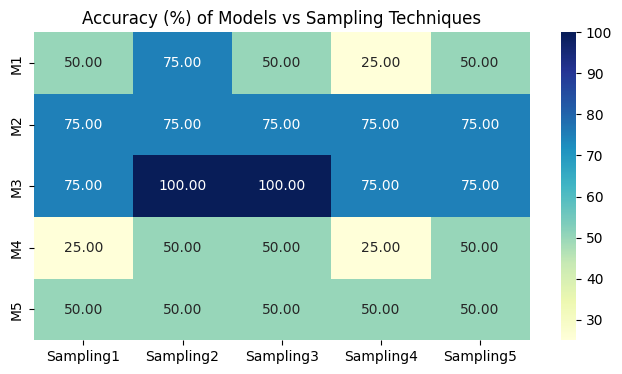

In [12]:
plt.figure(figsize=(8, 4))
sns.heatmap(results.astype(float), annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Accuracy (%) of Models vs Sampling Techniques')
plt.show()

## 5) Determine Best Sampling Technique for Each Model

In [13]:
best_for_each_model = results.idxmax(axis=1).to_frame(name='Best Sampling')
best_for_each_model['Best Accuracy (%)'] = results.max(axis=1).values
display(best_for_each_model)

global_best_pair = results.stack().idxmax()
global_best_value = results.stack().max()
print(f'Overall best: Model {global_best_pair[0]} with {global_best_pair[1]} -> {global_best_value:.2f}%')

,Best Sampling,Best Accuracy (%)
M1,Sampling2,75.0
M2,Sampling1,75.0
M3,Sampling2,100.0
M4,Sampling2,50.0
M5,Sampling1,50.0


Overall best: Model M3 with Sampling2 -> 100.00%
